<a href="https://colab.research.google.com/github/AlwaysDageyra/Bille--initiative-/blob/main/test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
import pandas as pd
import numpy as np

In [4]:
from google.colab import files

In [5]:
uploaded=files.upload()

Saving student-por.csv to student-por.csv


In [9]:
df = pd.read_csv("student-por.csv", sep=';')
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [10]:
df["at_risk"] = (df["G3"] < 10).astype(int)
df["at_risk"].value_counts(normalize=True)

,proportion
at_risk,
0,0.845917
1,0.154083


In [11]:
numeric_features = [
    "studytime",
    "failures",
    "famrel",
    "health",
    "absences"
]

categorical_features = [
    "schoolsup",
    "famsup",
    "activities",
    "higher",
    "internet"
]

x = df[numeric_features + categorical_features].copy()
y = df["at_risk"]

In [12]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"))
    ]
)

In [14]:
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7923076923076923
Precision: 0.36
Recall: 0.45
F1 score: 0.4
Confusion matrix:
 [[94 16]
 [11  9]]


In [15]:
from sklearn.tree import DecisionTreeClassifier

In [16]:
dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
    ]
)

dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 score:", f1_score(y_test, y_pred_dt))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.7692307692307693
Precision: 0.1875
Recall: 0.15
F1 score: 0.16666666666666666
Confusion matrix:
 [[97 13]
 [17  3]]


In [17]:
comparison = pd.DataFrame({
    "Logistic Regression": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    "Decision Tree": [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt)
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score"])

comparison

,Logistic Regression,Decision Tree
Accuracy,0.792308,0.769231
Precision,0.360000,0.187500
Recall,0.450000,0.150000
F1 Score,0.400000,0.166667


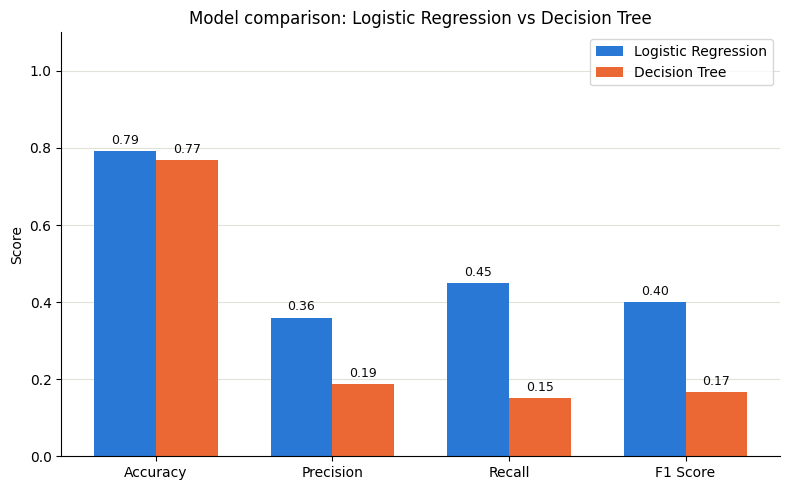

In [19]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
lr_scores = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]
dt_scores = [
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt)
]

x_pos = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x_pos - width/2, lr_scores, width, label="Logistic Regression", color="#2a78d6")
bars2 = ax.bar(x_pos + width/2, dt_scores, width, label="Decision Tree", color="#eb6834")

# direct value labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9, color="#0b0b0b")

ax.set_ylabel("Score")
ax.set_title("Model comparison: Logistic Regression vs Decision Tree")
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()